In [1]:
import sys
sys.path.insert(0, '/user/bnc2119/drd')
import numpy as np, pandas as pd
import umap
import matplotlib.pyplot as plt
import seaborn as sns
from utils import load_and_split, get_teacher_embeddings
from src.drd import AutoEncoder
import seaborn as sns
import torch
import scanpy as sc
PATH_PREFIX = '/shared/share_mala/irchang/drd' 
from pathlib import Path
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.ticker as ticker
%load_ext autoreload
%autoreload 2

/user/bnc2119/.conda/envs/drd/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-12-22 10:45:45.739959: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766418345.751476   88634 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766418345.755189   88634 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766418345.764431   88634 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once

In [13]:
PATH_PREFIX = "/shared/share_mala/irchang/drd"
# loading AE
def load_trained_ae(ckpt_path, input_dim, hidden_dims, latent_dim=2, batchnorm=False):
    import sys, os
    old_stdout = sys.stdout
    sys.stdout = open(os.devnull, "w")
    model = AutoEncoder(
        input_dim=input_dim,
        latent_dim=latent_dim,
        hidden_dims=hidden_dims,
        activation=torch.nn.SELU,            # match training!
        bottleneck_activation=None,
        use_batchnorm = batchnorm
    )
    sys.stdout = old_stdout

    sd = torch.load(ckpt_path, map_location="cpu")

    # unwrap to the real state dict
    if isinstance(sd, dict) and "model" in sd and isinstance(sd["model"], dict):
        sd = sd["model"]
    elif isinstance(sd, dict) and "state_dict" in sd and isinstance(sd["state_dict"], dict):
        sd = sd["state_dict"]

    # remove DDP prefixes if any
    sd = {k.replace("module.", ""): v for k, v in sd.items()}

    # load STRICTLY so we fail fast if something doesn’t match
    missing, unexpected = model.load_state_dict(sd, strict=False)
    print(f"loaded params: {len(sd)} | missing={len(missing)} | unexpected={len(unexpected)}")
    if missing or unexpected:
        print("⚠️ Check architecture/keys. Example missing:", missing[:3], "unexpected:", unexpected[:3])

    model.eval()
    return model

### MNIST

In [88]:
# Batch-effect prototype on MNIST — Step 1: Define artificial batches
#
# This cell sets up *batch effects* as simple, reproducible image perturbations.
# It does NOT require internet or torchvision. If you already have MNIST arrays
# (X: [N,28,28] or [N,784], y: [N]), you can pass them to `make_artificial_batches`.
#
# Batches:
#   A: identity (no change)
#   B: additive Gaussian noise
#   C: brightness/contrast shift
#   D: smoothing (box blur via neighbor-averaging using np.roll)
#
# The output returns:
#   X_aug  : augmented images (same shape as input)
#   y_bio  : the original digit labels (unchanged)
#   y_batch: batch IDs as strings: "A", "B", "C", "D"
#
# A small smoke test at the bottom fabricates toy "MNIST-like" images just to show usage.
import numpy as np
from typing import Tuple, Dict, Optional

def _ensure_images_shape(X: np.ndarray) -> Tuple[np.ndarray, bool]:
    """
    Ensure X is shaped as (N, 28, 28) in float32 [0,1].
    Returns (X_img, was_flattened) so we can restore original shape later.
    """
    X = np.asarray(X)
    if X.ndim == 2 and X.shape[1] == 784:
        X_img = X.reshape(-1, 28, 28)
        was_flattened = True
    elif X.ndim == 3 and X.shape[1:] == (28, 28):
        X_img = X
        was_flattened = False
    else:
        raise ValueError("X must be shape (N,784) or (N,28,28).")
    # Normalize if needed to [0,1]
    X_img = X_img.astype(np.float32)
    if X_img.max() > 1.0:
        X_img = X_img / 255.0
    X_img = np.clip(X_img, 0.0, 1.0)
    return X_img, was_flattened

def _restore_shape(X_img: np.ndarray, was_flattened: bool) -> np.ndarray:
    return X_img.reshape(len(X_img), -1) if was_flattened else X_img

def _apply_noise(img: np.ndarray, sigma: float, rng: np.random.Generator) -> np.ndarray:
    noise = rng.normal(0.0, sigma, size=img.shape).astype(np.float32)
    out = img + noise
    return np.clip(out, 0.0, 1.0)

def _apply_brightness_contrast(img: np.ndarray, alpha: float, beta: float) -> np.ndarray:
    # out = alpha * img + beta, then clip
    out = alpha * img + beta
    return np.clip(out, 0.0, 1.0).astype(np.float32)

def _apply_smoothing(img: np.ndarray, n_iter: int = 1) -> np.ndarray:
    # Cheap box-blur: average with 4-neighbors using np.roll; repeat n_iter times.
    out = img.copy()
    for _ in range(n_iter):
        up    = np.roll(out, shift=-1, axis=0)
        down  = np.roll(out, shift=+1, axis=0)
        left  = np.roll(out, shift=-1, axis=1)
        right = np.roll(out, shift=+1, axis=1)
        out = (out + up + down + left + right) / 5.0

    return out.astype(np.float32)

def make_artificial_batches(
    X: np.ndarray,
    y: np.ndarray,
    batch_fracs: Dict[str, float] = {"A": 0.25, "B": 0.25, "C": 0.25, "D": 0.25},
    noise_sigma: float = 0.20,
    alpha: float = 1.20,   # contrast multiplier
    beta: float = 0.05,    # brightness offset (on [0,1] scale)
    smooth_iters: int = 1,
    seed: int = 0,
    stratify_by_label: bool = True,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Assign each sample to a batch A/B/C/D and apply the corresponding perturbation.
    - If stratify_by_label=True, we assign batches within each digit to keep digit proportions balanced.
    - Otherwise we assign globally by given fractions.
    Returns: (X_aug, y_bio, y_batch_str)
    """
    assert abs(sum(batch_fracs.values()) - 1.0) < 1e-6, "batch_fracs must sum to 1.0"
    X_img, was_flattened = _ensure_images_shape(X)
    y = np.asarray(y)
    assert len(X_img) == len(y), "X and y must have same length"
    
    rng = np.random.default_rng(seed)
    N = len(X_img)
    batch_ids = np.empty(N, dtype=object)

    def assign_indices(idxs: np.ndarray, fracs: Dict[str, float]) -> Dict[str, np.ndarray]:
        n = len(idxs)
        counts = {k: int(round(fracs[k] * n)) for k in fracs}
        # fix rounding to sum exactly n
        diff = n - sum(counts.values())
        if diff != 0:
            # adjust the largest-fraction key
            k_adj = max(fracs, key=fracs.get)
            counts[k_adj] += diff
        rng.shuffle(idxs)
        splits = {}
        start = 0
        for k in fracs:
            end = start + counts[k]
            splits[k] = idxs[start:end]
            start = end
        return splits

    if stratify_by_label:
        for digit in np.unique(y):
            idxs = np.where(y == digit)[0]
            splits = assign_indices(idxs, batch_fracs)
            for k, ss in splits.items():
                batch_ids[ss] = k
    else:
        idxs = np.arange(N)
        splits = assign_indices(idxs, batch_fracs)
        for k, ss in splits.items():
            batch_ids[ss] = k

    # Apply perturbations per batch
    X_out = np.empty_like(X_img, dtype=np.float32)
    for b in ["A", "B", "C", "D"]:
        idxs = np.where(batch_ids == b)[0]
        if len(idxs) == 0:
            continue
        imgs = X_img[idxs]
        if b == "A":    # identity
            X_out[idxs] = imgs
        elif b == "B":  # noise
            X_out[idxs] = np.stack([_apply_noise(im, noise_sigma, rng) for im in imgs])
        elif b == "C":  # brightness/contrast
            X_out[idxs] = np.stack([_apply_brightness_contrast(im, alpha, beta) for im in imgs])
        elif b == "D":  # smoothing
            X_out[idxs] = np.stack([_apply_smoothing(im, n_iter=smooth_iters) for im in imgs])
        else:
            raise ValueError(f"Unknown batch key {b}")

    X_aug = _restore_shape(X_out, was_flattened)
    y_bio = y.copy()
    y_batch = batch_ids.astype(str)
    return X_aug, y_bio, y_batch

In [102]:
mnist = fetch_openml('mnist_784', version=1)
data = mnist.data.values[:10000, :]
labs = mnist.target.values[:10000]
test_data = mnist.data.values[10000:11000, :]
test_labs = mnist.target.values[10000:11000]

scaler = StandardScaler().fit(data)
X = data/255
X, X_A_ho, y, y_A_ho = train_test_split(X, labs, test_size=0.2, random_state=0)

X_test = test_data / 255

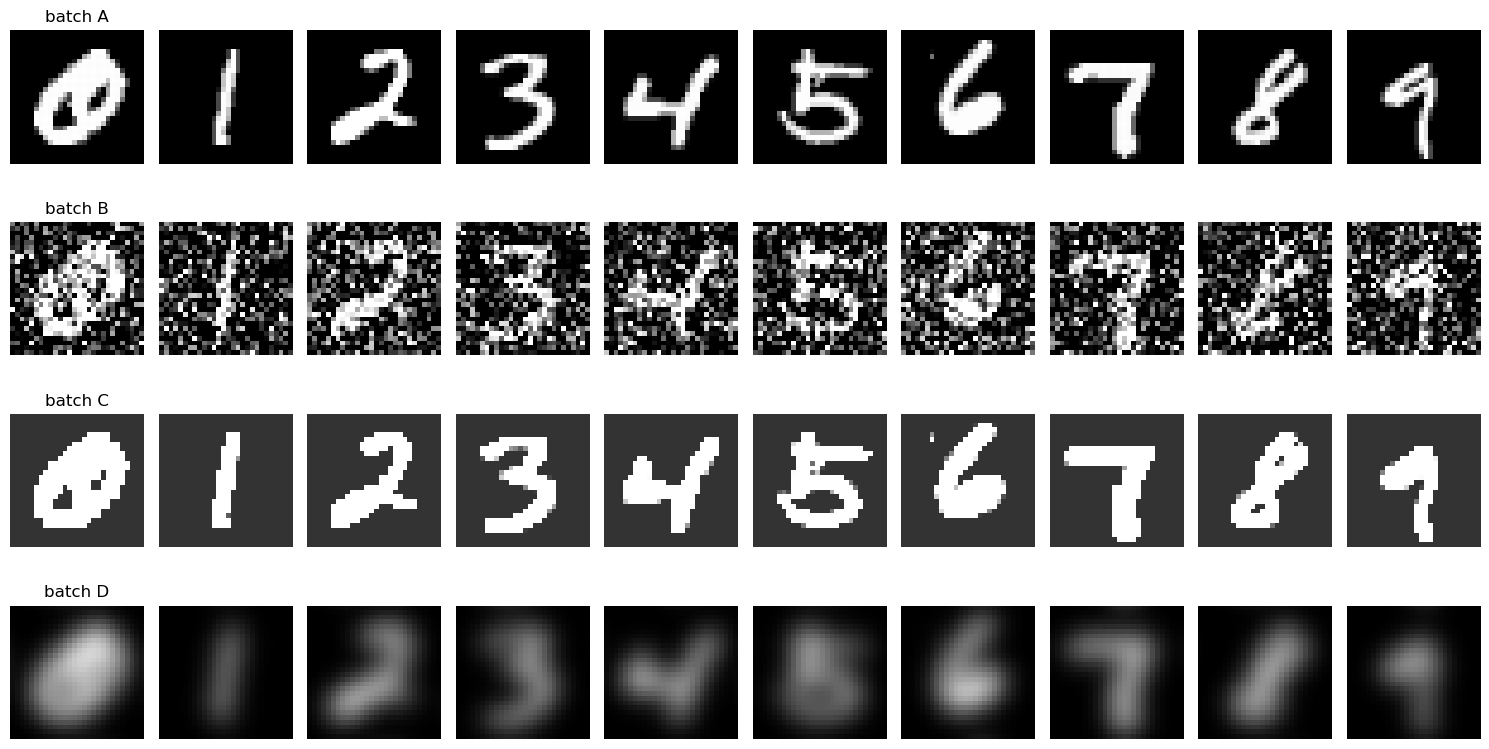

In [119]:
X_demo = np.vstack([X_test]).reshape((len(X_test), 28, 28))
# mn = X_demo.min(axis=(1,2), keepdims=True)
# mx = X_demo.max(axis=(1,2), keepdims=True)
# print(mn, mx)
# X_demo = (X_demo - mn) / (mx - mn + 1e-8)
y_demo = np.concatenate([test_labs])

X_B_aug_demo, y_B_bio_demo, y_B_batch_demo = make_artificial_batches(
    X_demo, y_demo,
    batch_fracs={"A":0,"B":1,"C":0,"D":0},
    noise_sigma=0.5,
    seed=0, stratify_by_label=True
)

X_C_aug_demo, y_C_bio_demo, y_C_batch_demo = make_artificial_batches(
    X_demo, y_demo,
    batch_fracs={"A":0,"B":0,"C":1,"D":0},
    alpha=10, beta=0.2,
    seed=0, stratify_by_label=True
)

X_D_aug_demo, y_D_bio_demo, y_D_batch_demo = make_artificial_batches(
    X_demo, y_demo,
    batch_fracs={"A":0,"B":0,"C":0,"D":1},
    seed=0, stratify_by_label=True, smooth_iters = 20
)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 10, figsize=(15, 8))
batches = ["A","B","C","D"]
for col, digit in enumerate(['0','1','2','3','4','5','6', '7', '8', '9']):
    for row, b in enumerate(batches):
        axes[row, col].axis("off")
        if col == 0: axes[row, col].set_title(f"batch {b}")
    selected_idx = 0
    idxs = np.where((y_demo == digit))[0]
    axes[0, col].imshow(X_demo[idxs[selected_idx]], cmap="gray", vmin=0, vmax=1)
    axes[1, col].imshow(X_B_aug_demo[idxs[selected_idx]], cmap="gray", vmin=0, vmax=1)
    axes[2, col].imshow(X_C_aug_demo[idxs[selected_idx]], cmap="gray", vmin=0, vmax=1)
    axes[3, col].imshow(X_D_aug_demo[idxs[selected_idx]], cmap="gray", vmin=0, vmax=1)

plt.tight_layout()
plt.show()


In [104]:
teacher_embed = np.load(Path(PATH_PREFIX) / f"embeddings/mnist_umap_18_0.1_0_train.npy")
student_umap = load_trained_ae('/shared/share_mala/irchang/drd/tmp_results/chkpt/mnist/umap2_18_0.1_0_ckpts/final.pt',
                input_dim=784,
                hidden_dims=[1000, 1000, 1000, 1000, 1000],
                latent_dim=2, batchnorm=False)
student_recon, student_embed_umap = student_umap(torch.tensor(X, dtype=torch.float32))
per_sample_recon = np.mean((student_recon.detach().numpy() - X)**2, axis=1)

loaded params: 24 | missing=0 | unexpected=0


In [120]:
X_A = X_demo.reshape(-1, 784)
X_A_recon, X_A_embed  = student_umap(torch.tensor(X_A, dtype=torch.float32))
A_recon_loss = np.mean((X_A_recon.detach().numpy() - X_A)**2, axis=1)

X_B = X_B_aug_demo.reshape(-1, 784)
X_B_recon, X_B_embed = student_umap(torch.tensor(X_B, dtype=torch.float32))
B_recon_loss = np.mean((X_B_recon.detach().numpy() - X_B)**2, axis=1)

X_C = X_C_aug_demo.reshape(-1, 784)
X_C_recon, X_C_embed = student_umap(torch.tensor(X_C, dtype=torch.float32))
C_recon_loss = np.mean((X_C_recon.detach().numpy() - X_C)**2, axis=1)

X_D = X_D_aug_demo.reshape(-1, 784)
X_D_recon, X_D_embed = student_umap(torch.tensor(X_D, dtype=torch.float32))
D_recon_loss = np.mean((X_D_recon.detach().numpy() - X_D)**2, axis=1)

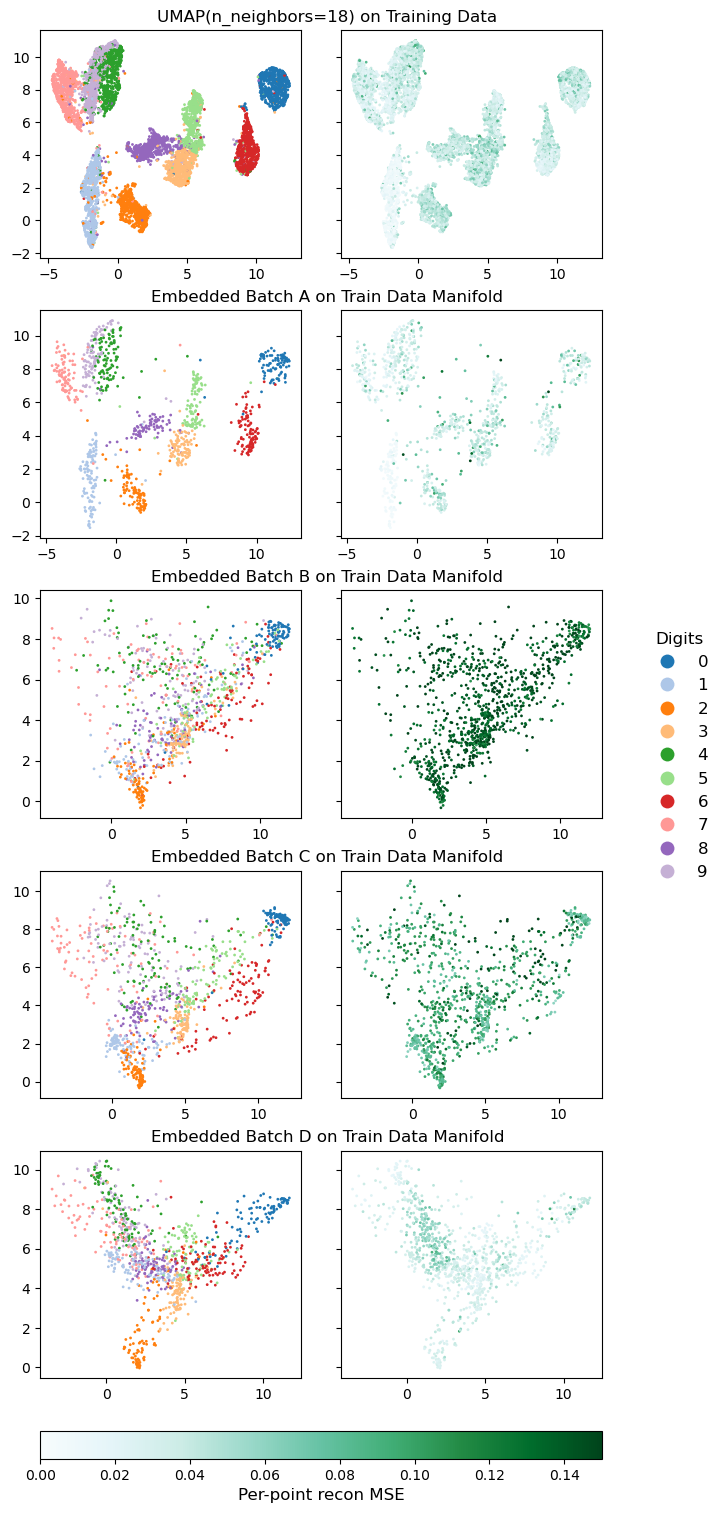

In [122]:
label_colors = [plt.get_cmap("tab20")(i) for i in range(10)]
mnist_palette = {digit: col for digit, col in zip(y.value_counts().index, label_colors)}
recon_cmap = sns.color_palette("BuGn", as_cmap=True)
norm = plt.Normalize(vmin=0, vmax=0.15)
fig, axes = plt.subplots(5, 2, figsize=(6,15), constrained_layout=True, sharex='row', sharey='row')
axes_flat = axes.flatten()

# 1st row
sns.scatterplot(
    x=student_embed_umap.detach().numpy()[:, 0], y=student_embed_umap.detach().numpy()[:, 1],hue=y,
    palette=mnist_palette, s=4, linewidth=0, legend=True, rasterized=True,ax=axes_flat[0]
)
handles, labels = axes_flat[0].get_legend_handles_labels()
axes_flat[0].legend_.remove()
fig.legend(
    handles, labels,
    loc='center left', bbox_to_anchor=(1.05, 0.5),
    frameon=False, title='Digits', fontsize=12, markerscale=5, title_fontsize=12, ncol=1,
)
axes_flat[0].set_title('UMAP(n_neighbors=18) on Training Data', x=1.1)
sns.scatterplot(
    x=student_embed_umap.detach().numpy()[:, 0], y=student_embed_umap.detach().numpy()[:, 1],hue=per_sample_recon,
    palette=recon_cmap, hue_norm=norm, s=4, linewidth=0, legend=False, rasterized=True,ax=axes_flat[1]
)

# 2nd row
sns.scatterplot(
    x=X_A_embed.detach().numpy()[:, 0], y=X_A_embed.detach().numpy()[:, 1],hue=y_demo,
    palette=mnist_palette, s=4, linewidth=0, legend=False, rasterized=True, ax=axes_flat[2]
)
axes_flat[2].set_title('Embedded Batch A on Train Data Manifold', x=1.1)
sns.scatterplot(
    x=X_A_embed.detach().numpy()[:, 0], y=X_A_embed.detach().numpy()[:, 1],hue=A_recon_loss,
    palette=recon_cmap, hue_norm=norm, s=4, linewidth=0, legend=False, rasterized=True, ax=axes_flat[3]
)

# 3rd row
sns.scatterplot(
    x=X_B_embed.detach().numpy()[:, 0], y=X_B_embed.detach().numpy()[:, 1],hue=y_demo,
    palette=mnist_palette, s=4, linewidth=0,  legend=False, ax=axes_flat[4])
sns.scatterplot(
    x=X_B_embed.detach().numpy()[:, 0], y=X_B_embed.detach().numpy()[:, 1],hue=B_recon_loss,
    palette=recon_cmap, hue_norm=norm, s=4, linewidth=0,  legend=False, ax=axes_flat[5])
axes_flat[4].set_title('Embedded Batch B on Train Data Manifold', x=1.1)

# 4th row
sns.scatterplot(
    x=X_C_embed.detach().numpy()[:, 0], y=X_C_embed.detach().numpy()[:, 1],hue=y_demo,
    palette=mnist_palette, s=4, linewidth=0,  legend=False, ax=axes_flat[6])
sns.scatterplot(
    x=X_C_embed.detach().numpy()[:, 0], y=X_C_embed.detach().numpy()[:, 1],hue=C_recon_loss,
    palette=recon_cmap, hue_norm=norm, s=4, linewidth=0,  legend=False, ax=axes_flat[7])
axes_flat[6].set_title('Embedded Batch C on Train Data Manifold', x=1.1)

# 5th row
sns.scatterplot(
    x=X_D_embed.detach().numpy()[:, 0], y=X_D_embed.detach().numpy()[:, 1],hue=y_demo,
    palette=mnist_palette, s=4, linewidth=0,  legend=False, ax=axes_flat[8])
sns.scatterplot(
    x=X_D_embed.detach().numpy()[:, 0], y=X_D_embed.detach().numpy()[:, 1],hue=D_recon_loss,
    palette=recon_cmap, hue_norm=norm, s=4, linewidth=0,  legend=False, ax=axes_flat[9])
axes_flat[8].set_title('Embedded Batch D on Train Data Manifold', x=1.1)


sm = plt.cm.ScalarMappable(cmap=recon_cmap, norm=norm)
cb = fig.colorbar(sm, ax=axes, orientation="horizontal", fraction=0.05, pad=0.02)
cb.set_label("Per-point recon MSE", fontsize=12)
plt.show()

### Macaque

In [3]:
X, X_test, y, y_test = load_and_split("macaque", test_size=0.2, seed=0, labels=True)
cmap = plt.get_cmap("tab20")
unique_labels = np.unique(y)
c_dict = {l: cmap(i) for i, l in enumerate(unique_labels)}

In [4]:
teacher_embed = np.load(Path(PATH_PREFIX) / f"embeddings/macaque_umap_18_0.1_0_train.npy")

In [5]:
student = load_trained_ae(Path(PATH_PREFIX) / 'tmp_results/chkpt/macaque/umap2_18_0.1_0_ckpts/final.pt',
                input_dim=100,
                hidden_dims=[700] * 15,
                latent_dim=2, batchnorm=False)
student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
student_test_recon, student_test_embed = student(torch.tensor(X_test, dtype=torch.float32))
per_sample_recon = np.mean((student_recon.detach().numpy() - X)**2, axis=1)
per_sample_test_recon = np.mean((student_test_recon.detach().numpy() - X_test)**2, axis=1)

loaded params: 64 | missing=0 | unexpected=0


In [6]:
macaque2 = pd.read_csv('/shared/share_mala/irchang/drd/tmp/macaque2_pc100.csv')
macaque3 = pd.read_csv('/shared/share_mala/irchang/drd/tmp/macaque3_pc100.csv')
_, macaque2_test = train_test_split(macaque2, test_size=0.5, random_state=0)
_, macaque3_test = train_test_split(macaque3, test_size=0.5, random_state=0)
X2, y2 = macaque2_test.drop('labels', axis=1).values, macaque2_test['labels'].values
X3, y3 = macaque3_test.drop('labels', axis=1).values, macaque3_test['labels'].values

In [7]:
batch_recon2, batch_embed2 = student(torch.tensor(X2, dtype=torch.float32))
per_sample_recon_2 = np.mean((batch_recon2.detach().numpy() - X2)**2, axis=1)
batch_recon3, batch_embed3 = student(torch.tensor(X3, dtype=torch.float32))
per_sample_recon_3 = np.mean((batch_recon3.detach().numpy() - X3)**2, axis=1)

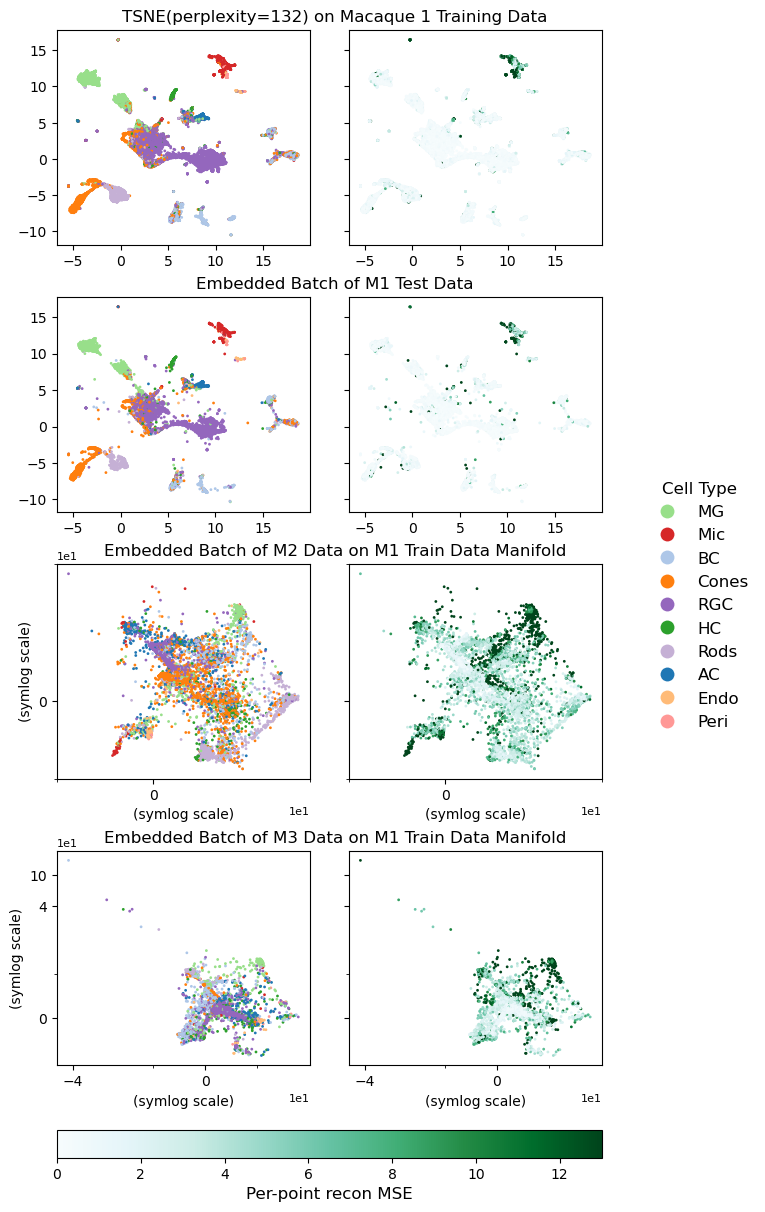

In [11]:
fig, axes = plt.subplots(4, 2, figsize=(6,12), constrained_layout=True, sharex='row', sharey='row')
axes_flat = axes.flatten()
recon_cmap = sns.color_palette("BuGn", as_cmap=True)
norm = plt.Normalize(vmin=0, vmax=13)

# 1st row
sns.scatterplot(
    x=student_embed.detach().numpy()[:, 0], y=student_embed.detach().numpy()[:, 1],hue=y,
    palette=c_dict, s=4, linewidth=0, legend=True, rasterized=True,ax=axes_flat[0]
)
handles, labels = axes_flat[0].get_legend_handles_labels()
axes_flat[0].legend_.remove()
fig.legend(
    handles, labels,
    loc='center left', bbox_to_anchor=(1.05, 0.5),
    frameon=False, title='Cell Type', fontsize=12, markerscale=5, title_fontsize=12, ncol=1,
)
axes_flat[0].set_title('TSNE(perplexity=132) on Macaque 1 Training Data', x=1.1)
sns.scatterplot(
    x=student_embed.detach().numpy()[:, 0], y=student_embed.detach().numpy()[:, 1],hue=per_sample_recon,
    palette=recon_cmap, hue_norm=norm, s=4, linewidth=0, legend=False, rasterized=True,ax=axes_flat[1]
)

# 2nd row
sns.scatterplot(
    x=student_test_embed.detach().numpy()[:, 0], y=student_test_embed.detach().numpy()[:, 1],hue=y_test,
    palette=c_dict, s=4, linewidth=0, legend=False, rasterized=True, ax=axes_flat[2]
)
axes_flat[2].set_title('Embedded Batch of M1 Test Data', x=1.1)
sns.scatterplot(
    x=student_test_embed.detach().numpy()[:, 0], y=student_test_embed.detach().numpy()[:, 1],hue=per_sample_test_recon,
    palette=recon_cmap, hue_norm=norm, s=4, linewidth=0, legend=False, rasterized=True, ax=axes_flat[3]
)

# 3rd row
sns.scatterplot(
    x=batch_embed2.detach().numpy()[:, 0], y=batch_embed2.detach().numpy()[:, 1],hue=y2,
    palette=c_dict, s=4, linewidth=0,  legend=False, ax=axes_flat[4])
axes_flat[4].set_yscale("symlog", linthresh=40)
axes_flat[4].set_xscale("symlog", linthresh=40)
axes_flat[4].set_yticks([-100, -40, 0, 40, 100])
axes_flat[4].set_xticks([-200, -40, 0, 40, 100])
axes_flat[4].yaxis.set_major_formatter(ticker.ScalarFormatter())
axes_flat[4].xaxis.set_major_formatter(ticker.ScalarFormatter())
axes_flat[4].set_ylabel("(symlog scale)")
axes_flat[4].set_xlabel("(symlog scale)")
axes_flat[4].ticklabel_format(style='sci', axis='both', scilimits=(1,1))
sns.scatterplot(
    x=batch_embed2.detach().numpy()[:, 0], y=batch_embed2.detach().numpy()[:, 1],hue=per_sample_recon_2,
    palette=recon_cmap, hue_norm=norm, s=4, linewidth=0,  legend=False, ax=axes_flat[5])
axes_flat[5].set_ylabel("(symlog scale)")
axes_flat[5].set_xlabel("(symlog scale)")
axes_flat[4].set_title('Embedded Batch of M2 Data on M1 Train Data Manifold', x=1.1)

sns.scatterplot(
    x=batch_embed3.detach().numpy()[:, 0], y=batch_embed3.detach().numpy()[:, 1],hue=y3,
    palette=c_dict, s=4, linewidth=0,  legend=False, ax=axes_flat[6])
axes_flat[6].set_yscale("symlog", linthresh=20)
axes_flat[6].set_xscale("symlog", linthresh=20)
axes_flat[6].set_yticks([-100, -40, 0, 40, 100])
axes_flat[6].set_xticks([-1000, -200, -40, 0, 40, 100])
axes_flat[6].yaxis.set_major_formatter(ticker.ScalarFormatter())
axes_flat[6].xaxis.set_major_formatter(ticker.ScalarFormatter())
axes_flat[6].set_ylabel("(symlog scale)")
axes_flat[6].set_xlabel("(symlog scale)")
axes_flat[6].ticklabel_format(style='sci', axis='both', scilimits=(1,1))
sns.scatterplot(
    x=batch_embed3.detach().numpy()[:, 0], y=batch_embed3.detach().numpy()[:, 1],hue=per_sample_recon_3,
    palette=recon_cmap, hue_norm=norm, s=4, linewidth=0,  legend=False, ax=axes_flat[7])
axes_flat[7].set_ylabel("(symlog scale)")
axes_flat[7].set_xlabel("(symlog scale)")
axes_flat[6].set_title('Embedded Batch of M3 Data on M1 Train Data Manifold', x=1.1)

for axx in axes_flat[4:]:
    axx.xaxis.get_offset_text().set_fontsize(8)
    axx.yaxis.get_offset_text().set_fontsize(8)

sm = plt.cm.ScalarMappable(cmap=recon_cmap, norm=norm)
cb = fig.colorbar(sm, ax=axes, orientation="horizontal", fraction=0.05, pad=0.02)
cb.set_label("Per-point recon MSE", fontsize=12)
plt.show()

In [3]:
import scanpy as sc
adata = sc.read_h5ad("/shared/share_mala/irchang/drd/tmp/GSE118546_fovea.h5ad")
# Basic processing (idempotent if done already)
markers = {
    "Rods": ["RHO", "PDC", "NRL", "SAG", "GNAT1", "GNGT1", "NR2E3", "GNB1"],
    "Cones": ["ARR3", "RCVRN", "GNAT2", "GNGT2", "OPN1LW", "OPN1SW", "OPN1MW", "PDE6H", "GUCA1A"],
    "HC": ["LHX1", "ONECUT1", "ONECUT2", "CALB1"],
    "BC": ["VSX2", "OTX2", "GRM6", "PRKCA", "TRPM1", "GRIK1", "VSX1", "CABP5"],
    "AC": ["TFAP2A", "TFAP2B", "TFAP2C", "GAD1", "GAD2", "SLC6A9", "C1QL1", "C1QL2"],
    "RGC": ["RBPMS", "POU4F1", "POU4F2", "POU4F3", "THY1", "SLC17A6", "NEFL", "NEFM", "SNCG"],
    "MG": ["RLBP1", "GLUL", "APOE", "CRABP1", "CLU", "SLC1A3", "DKK3", "CRYM"],
    "Peri": ["RGC5", "MGP", "KCNJ8", "MYL9", "COL4A1"], 
    "Mic": ["C1QA", "C1QB", "C1QC", "HEXB", "CTSS", "P2RY12", "TMEM119", "B2M"],
    "Endo":	["CLDN5", "IGFBP7", "COL4A1"]
}

# Score each program
for k, genes in markers.items():
    present = [g for g in genes if g in adata.var_names]
    if present:
        sc.tl.score_genes(adata, gene_list=present, score_name=f"score_{k}", use_raw=False)

# Simple rule-based assignment from scores (you can refine later)
order = list(markers.keys())  # priority order
scores = [f"score_{k}" for k in order if f"score_{k}" in adata.obs]
adata.obs["celltype_guess"] = pd.Series(index=adata.obs_names, dtype="object")

if scores:
    score_mat = adata.obs[scores].to_numpy()
    best = score_mat.argmax(1)
    adata.obs["celltype_guess"] = np.array([order[i] for i in best])

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=3000)
adata = adata[:, adata.var["highly_variable"]].copy()


# Quick sanity plots
# sc.pl.tsne(adata, color=["cluster","celltype_guess","macaque_id"], size=5, wspace=0.4)

In [32]:
adata

AnnData object with n_obs × n_vars = 132000 × 3000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'macaque_id', 'ident', 'score_Rods', 'score_Cones', 'score_HC', 'score_BC', 'score_AC', 'score_RGC', 'score_MG', 'score_Peri', 'score_Mic', 'score_Endo', 'celltype_guess'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'X_name', 'log1p', 'hvg'
    layers: 'counts'

In [ ]:
adata.var_names

Index(['LOC102117280', 'LYPD8', 'LOC102140806', 'LOC102115026', 'LOC102123824',
       'LOC102138413', 'LOC102141073', 'LOC102144693', 'LOC107128892',
       'LOC102139797',
       ...
       'LOC102141043', 'LOC107128557', 'LOC102117148', 'LOC102125235',
       'LOC102130876', 'LOC102136222', 'CETN2', 'PNCK', 'LOC102131120',
       'MSTRG.23238'],
      dtype='object', length=3000)

In [4]:
import pandas as pd
data_to_save = pd.DataFrame(adata.X.toarray(), index = adata.obs.index)
# data_to_save = data_to_save[adata.obs['macaque_id'] == "M3"]

In [5]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
data_scaled = StandardScaler().fit_transform(data_to_save)
data_pca = PCA(n_components=100, random_state=0).fit_transform(data_scaled)
data_to_save = pd.DataFrame(data_pca)

In [ ]:
# data_to_save['labels'] = adata.obs['celltype_guess'][adata.obs['macaque_id'] == "M3"].values
# data_to_save.to_csv('/shared/share_mala/irchang/drd/tmp/macaque3_pc100.csv', index=False)

In [6]:
tsne = TSNE(n_components=2, random_state=0, perplexity=132)
Z_tsne = tsne.fit_transform(data_pca)

Text(0.5, 1.0, 'TSNE(perplexity=132) fitted on all 4 macaques')

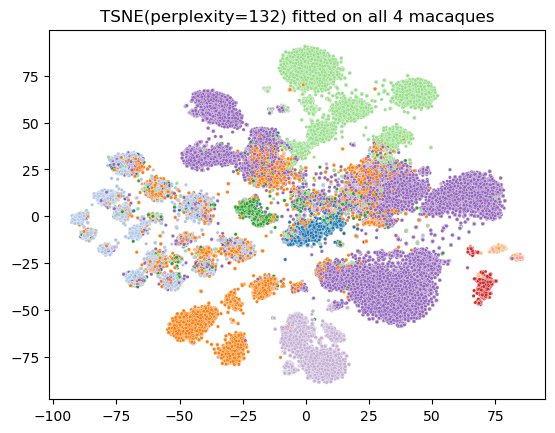

In [7]:
sns.scatterplot(x=Z_tsne[:,0], y=Z_tsne[:,1], s = 6, hue=adata.obs['celltype_guess'], legend=False, palette=c_dict)
plt.title('TSNE(perplexity=132) fitted on all 4 macaques')

Text(0.5, 1.0, 'TSNE(perplexity=132) fitted on all 4 macaques')

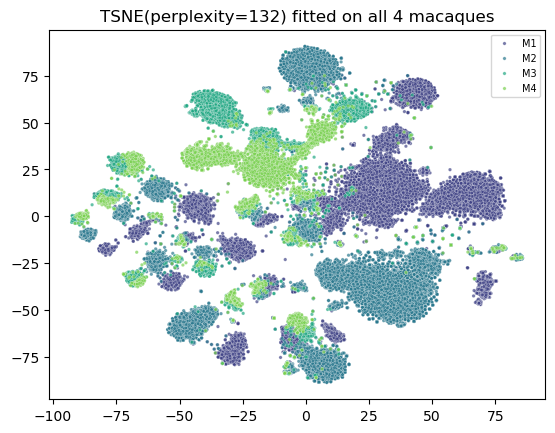

In [8]:
sns.scatterplot(x=Z_tsne[:,0], y=Z_tsne[:,1], s = 6, hue=adata.obs['macaque_id'],  palette='viridis', alpha=0.7, rasterized=True)
plt.legend(fontsize=7)
plt.title('TSNE(perplexity=132) fitted on all 4 macaques')

In [36]:
data_to_save['labels'] = adata.obs['celltype_guess'].values
data_to_save['macaque_id'] = adata.obs['macaque_id'].values
data_to_save

,0,1,2,3,4,5,6,7,8,9,...,92,93,94,95,96,97,98,99,labels,macaque_id
0,-2.954079,-4.345200,-1.378243,6.311030,6.057581,-1.113562,-1.378721,-0.578843,3.872104,1.445541,...,-0.307703,-0.053048,0.283342,0.257846,-0.060792,0.469997,0.019518,0.396803,Cones,M1
1,-0.748709,-0.910819,-2.505191,0.049146,-0.133986,-0.297894,-0.249767,-2.112056,1.378044,2.826946,...,-1.110531,-0.236533,1.131640,-0.363041,0.068316,0.076998,0.038659,-0.425274,HC,M1
2,5.387257,18.183874,9.235629,0.314976,0.749108,-1.093879,-1.147228,-2.190934,4.936161,1.290498,...,0.424632,-1.461540,-1.065258,-0.447340,1.581669,-0.028073,-0.965883,-1.393167,MG,M1
3,3.214907,18.306976,9.395370,0.884092,0.480569,-0.492026,0.234518,-0.418870,2.569574,-1.341781,...,-0.126661,1.020804,0.819205,-0.285417,0.283425,-1.125957,-0.670596,-0.240535,MG,M1
4,-2.638522,-3.914229,-2.536319,9.365832,9.040171,-2.092767,0.569923,-2.504452,6.203900,1.258671,...,-0.799825,-0.260420,-0.005216,0.115004,-0.409910,0.456418,-0.263309,-0.573274,Cones,M1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131995,-2.359880,-1.812841,-3.150257,5.969696,5.059112,-0.574527,0.905811,-0.159201,-3.874022,-1.607628,...,-0.030396,0.213226,0.820411,-0.165053,-0.277870,0.106320,-0.629057,0.158088,RGC,M4
131996,-0.812330,0.284670,-4.603324,-1.792543,-2.836862,0.293485,0.324496,0.430741,-3.573377,-1.326716,...,0.023158,-0.375778,-0.210033,0.222905,0.461109,0.418816,0.229618,0.097845,RGC,M4
131997,-0.219753,-0.518592,-5.813065,-4.204962,-3.344605,-0.650470,-1.024325,-3.435745,-2.681987,-1.554515,...,-0.116582,-0.041569,0.225468,-0.427800,0.223795,-0.180377,0.171051,0.010508,RGC,M4
131998,-5.383344,-11.959335,12.954655,-0.600410,-0.384019,2.122341,-12.460854,2.609831,-5.019061,-1.440738,...,1.067104,2.145916,-1.400273,0.352513,0.674120,-1.319836,0.551910,0.832862,Cones,M4


In [37]:
data_to_save.to_csv('preprocessed_all_macaques.csv', index=False)

In [ ]:
tsne = TSNE(n_components=2, random_state=0, perplexity=50)
# indicator = adata.obs['celltype_guess'].isin(['Rods', 'Cones'])
Z_tsne = tsne.fit_transform(data_pca)

<Axes: >

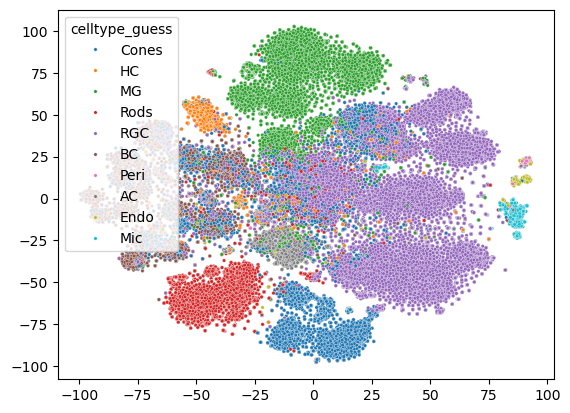

In [18]:
sns.scatterplot(x=Z_tsne[:,0], y=Z_tsne[:,1], s = 6,hue=adata.obs['celltype_guess'], legend=True)

<Axes: >

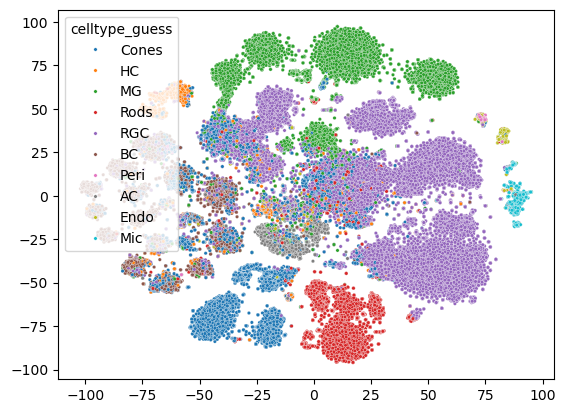

In [13]:
sns.scatterplot(x=Z_tsne[:,0], y=Z_tsne[:,1], s = 6,hue=adata.obs['celltype_guess'], legend=True)

<Axes: >

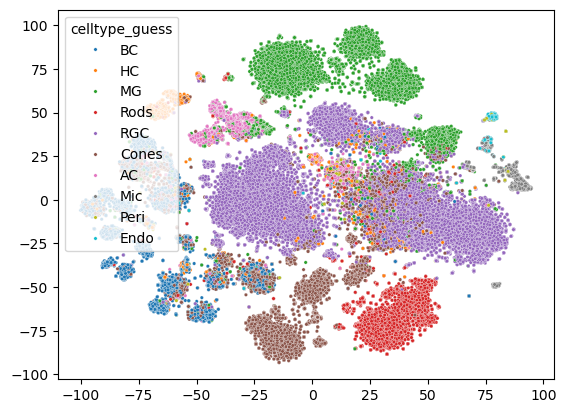

In [85]:
sns.scatterplot(x=Z_tsne[:,0], y=Z_tsne[:,1], s = 6,hue=adata.obs['celltype_guess'], legend=True)

<Axes: >

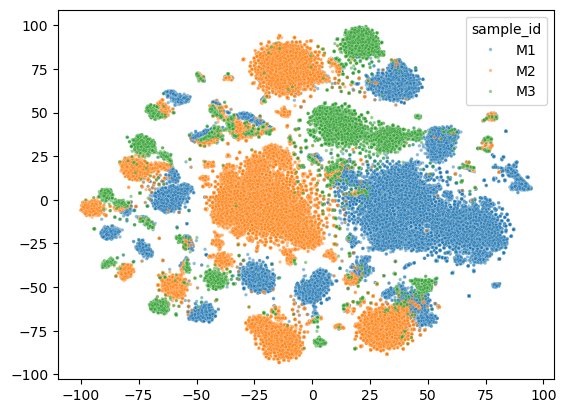

In [86]:
sns.scatterplot(x=Z_tsne[:,0], y=Z_tsne[:,1], s = 6,hue= macaque_id,alpha=0.5)

In [72]:
(macaque_id == "M3").sum()

np.int64(18000)

<Axes: >

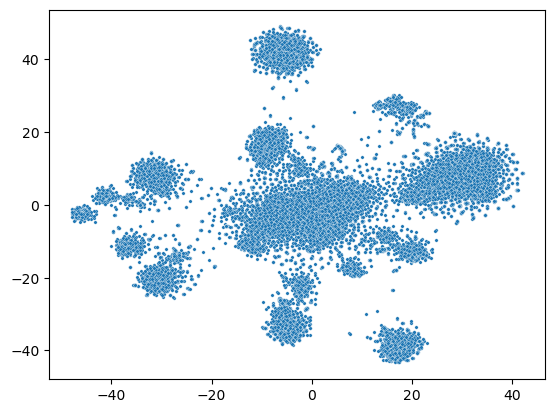

In [71]:
tsne = TSNE(n_components=2, random_state=0, perplexity=200)
Z_tsne = tsne.fit_transform(data_pca)
sns.scatterplot(x=Z_tsne[:,0], y=Z_tsne[:,1], s = 6)

In [77]:
import umap
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=0)
Z_umap = umap_model.fit_transform(data_pca)

/user/bnc2119/.conda/envs/drd/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/user/bnc2119/.conda/envs/drd/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [78]:
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=0)
Z_umap50 = umap_model.fit_transform(data_pca50)

/user/bnc2119/.conda/envs/drd/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/user/bnc2119/.conda/envs/drd/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


<Axes: >

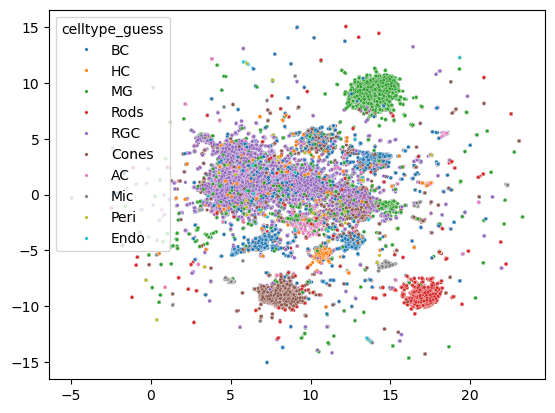

In [79]:
sns.scatterplot(x=Z_umap[:,0], y=Z_umap[:,1], s = 6, hue=adata.obs['celltype_guess'])

<Axes: >

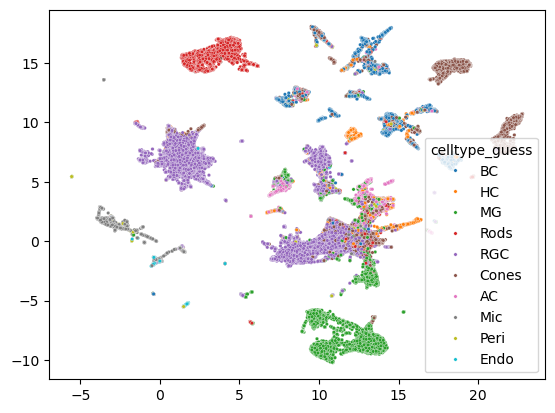

In [80]:
sns.scatterplot(x=Z_umap50[:,0], y=Z_umap50[:,1], s = 6, hue=adata.obs['celltype_guess'])

<Axes: >

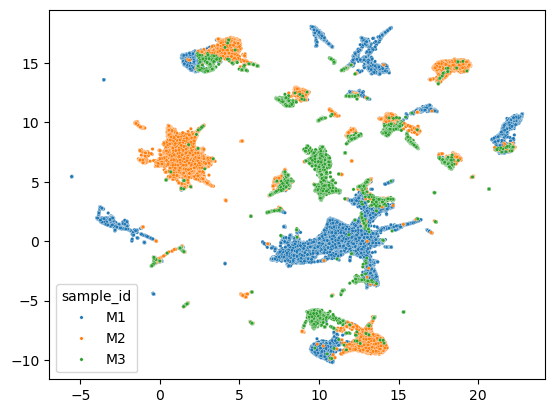

In [81]:
sns.scatterplot(x=Z_umap50[:,0], y=Z_umap50[:,1], s = 6, hue=macaque_id)